# Thai Receipt Validation Notebook
OCR field detection + ML classification for Thai receipts (~560 augmented images)

In [13]:
import os, re, time, json, pickle, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['font.family'] = ['DejaVu Sans']
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)
from openai import OpenAI, RateLimitError
print('Imports done')


Imports done


In [14]:
API_KEY = os.environ.get('TYPHOON_API_KEY', '')
if not API_KEY:
    raise ValueError('Please set the TYPHOON_API_KEY environment variable')
print('API key loaded')


API key loaded


In [15]:
FIELDS = [
    'has_store_name',     # ชื่อร้าน/บริษัท
    'has_store_address',  # ที่อยู่ร้าน
    'has_store_tax_id',   # เลขประจำตัวผู้เสียภาษีร้าน
    'has_date',           # วันที่
    'has_amount',         # ยอดรวม (ตัวเลข)
    'has_amount_words',   # จำนวนเงินเป็นตัวอักษร
    'has_signature',      # ลายเซ็น/ผู้รับรอง
    'has_mfu_name',       # ชื่อมหาวิทยาลัยแม่ฟ้าหลวง (ผู้รับบริการ)
    'has_mfu_address',    # ที่อยู่ MFU
    'has_mfu_tax_id',     # เลขประจำตัวผู้เสียภาษีของ MFU
]

THAI_MONTHS = (
    'มกราคม|ม\.ค\.|กุมภาพันธ์|ก\.พ\.|มีนาคม|มี\.ค\.|เมษายน|เม\.ย\.|'
    'พฤษภาคม|พ\.ค\.|มิถุนายน|มิ\.ย\.|กรกฎาคม|ก\.ค\.|'
    'สิงหาคม|ส\.ค\.|กันยายน|ก\.ย\.|ตุลาคม|ต\.ค\.|'
    'พฤศจิกายน|พ\.ย\.|ธันวาคม|ธ\.ค\.'
)
ENG_MONTHS = (
    'jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec|'
    'january|february|march|april|june|july|august|september|october|november|december'
)

def normalize(text):
    return re.sub(r'\s+', ' ', text.lower().strip())


In [16]:

# ── MFU-specific Detection Functions ────────────────────────────────

def detect_store_name(text):
    """ชื่อร้าน/บริษัท: Thai company suffixes + English business keywords."""
    t = normalize(text)
    thai = ['จำกัด','มหาชน','บริษัท','ห้างหุ้นส่วน','ร้าน','หจก.','บจก.','บมจ.']
    eng  = ['co.,ltd','co., ltd','ltd.','company','shop','store','bakery',
            'cafe','restaurant','hotel','hospital','clinic','center','centre',
            'service','technology','university','inc.','inc,']
    return int(any(kw in t for kw in thai + eng))


def detect_store_address(text):
    """ที่อยู่ร้าน: Thai address patterns."""
    thai_addr = ['หมู่','ตำบล','ต.','อำเภอ','อ.','จังหวัด','จ.',
                 'ถนน','ถ.','ซอย','ซ.','แขวง','เขต',
                 'กรุงเทพ','กรุงเทพมหานคร','นนทบุรี','ปทุมธานี',
                 'เชียงราย','เชียงใหม่','ขอนแก่น','โทร','โทรศัพท์']
    eng_addr  = ['road','rd.','street','st.','moo','any city']
    lines = text.split('\n')
    for line in lines:
        l = line.strip()
        if not l or len(l) < 4: continue
        if any(kw in l for kw in thai_addr): return 1
        if any(kw in l.lower() for kw in eng_addr): return 1
        if re.search(r'^\d+[\/]\d+', l): return 1
        if re.search(r'\b1\d{4}\b|\b[2-9]\d{4}\b', l): return 1
    return 0


def detect_store_tax_id(text):
    """เลขประจำตัวผู้เสียภาษีร้าน: 13-digit Thai tax ID."""
    thai_labels = ['เลขประจำตัวผู้เสียภาษี','เลขผู้เสียภาษี',
                   'เลขประจำตัวนิติบุคคล','tax id','tax no']
    t_lower = text.lower()
    for label in thai_labels:
        if label in text or label in t_lower:
            idx = text.find(label) if label in text else t_lower.find(label)
            if re.search(r'\d{10,13}', text[idx:idx+40]): return 1
    if re.findall(r'\b\d{13}\b', text): return 1
    if re.search(r'\b\d{4}[\-\s]?\d{3}[\-\s]?\d{5}[\-\s]?\d{1}\b', text): return 1
    return 0


def detect_date(text):
    """วันที่: Thai Buddhist Era dates, Thai month names, DD/MM/YY formats."""
    if re.search(r'วันที่\s*\d', text): return 1
    if re.search(THAI_MONTHS, text): return 1
    if re.search(r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b', text): return 1
    if re.search(r'(date|วัน)[:\s]+.{1,20}\d{2,4}', text, re.IGNORECASE): return 1
    if re.search(r'\b\d{1,2}\s+(' + ENG_MONTHS + r')\s+\d{4}\b', text, re.IGNORECASE): return 1
    return 0


def detect_amount(text):
    """ยอดรวม: total amount as a number."""
    thai_total = ['ยอดรวมทั้งหมด','จำนวนเงินรวมทั้งสิ้น','รวมทั้งสิ้น',
                  'ยอดรวม','รวมเป็นเงิน','ราคารวมสุทธิ','ยอดชำระ',
                  'รวมสุทธิ','จำนวนเงินทั้งสิ้น','รวมทั้งหมด']
    for kw in thai_total:
        if kw in text:
            idx = text.find(kw)
            if re.search(r'[฿]?[\d,]{3,}', text[idx:idx+60]): return 1
    if re.search(r'(grand\s*total|total\s*amount)[\s:]*[฿$]?[\d,]+\.?\d*',
                 text, re.IGNORECASE): return 1
    return 0


def detect_amount_in_words(text):
    """จำนวนเงินเป็นตัวอักษร: amount spelled out in Thai words."""
    t = normalize(text)
    if 'บาทถ้วน' in text or 'บาทถ้วน' in t: return 1
    thai_num_words = ['หนึ่ง','สอง','สาม','สี่','ห้า','หก',
                      'เจ็ด','แปด','เก้า','สิบ','ร้อย','พัน',
                      'หมื่น','แสน','ล้าน']
    if any(w in text for w in thai_num_words) and 'บาท' in text:
        for w in thai_num_words:
            if w in text:
                idx = text.find(w)
                if 'บาท' in text[idx:idx+60]: return 1
    if re.search(r'baht\s+only', t): return 1
    if re.search(r'\(?[a-z\s\-,]+baht', t): return 1
    return 0


def detect_signature(text):
    """ลายเซ็น: signature or authorisation field."""
    t = normalize(text)
    thai_sig = ['ผู้รับเงิน','ผู้จ่ายเงิน','ผู้อนุมัติ','ผู้ตรวจสอบ',
                'ผู้จัดการ','ผู้รับใบแจ้งหนี้','ผู้ออกใบแจ้งหนี้',
                'ผู้รับบิล','ผู้วางบิล','เจ้าหน้าที่การเงิน',
                'ผู้รับสินค้า','ผู้จัดทำ','ผู้ส่งสินค้า',
                'cashier','signature','signed by','approved by',
                'received by','authorised by','delivery by']
    return int(any(kw in t for kw in thai_sig))


def detect_mfu_name(text):
    """ชื่อมหาวิทยาลัยแม่ฟ้าหลวง (ผู้รับบริการ/ที่อยู่ผู้ซื้อ)."""
    t = normalize(text)
    mfu_keywords = [
        'มหาวิทยาลัยแม่ฟ้าหลวง', 'แม่ฟ้าหลวง', 'mae fah luang', 'mfu',
        'มฟล', 'mae fah luang university'
    ]
    return int(any(kw in t for kw in mfu_keywords))


def detect_mfu_address(text):
    """ที่อยู่ MFU: Mae Fah Luang University address."""
    t = normalize(text)
    mfu_addr_keywords = [
        '333', 'หมู่ที่ 1', 'ม.1', 'ตำบลท่าสุด', 'ท่าสุด',
        'อำเภอเมืองเชียงราย', 'เมืองเชียงราย', 'เชียงราย 57100',
        '57100', 'mfu road', 'nang lae'
    ]
    return int(any(kw in t for kw in mfu_addr_keywords))


def detect_mfu_tax_id(text):
    """เลขประจำตัวผู้เสียภาษีของ MFU: 0994000163481."""
    # MFU's official tax ID
    if '0994000163481' in text: return 1
    # Also check for label near MFU context
    t = normalize(text)
    if any(kw in t for kw in ['มฟล', 'แม่ฟ้าหลวง', 'mfu']):
        if re.search(r'\b\d{13}\b', text): return 1
    return 0


In [17]:
# ── Detection Functions (Thai-aware) ────────────────────────────────

def detect_store_name(text):
    """ชื่อร้าน/บริษัท: Thai company suffixes + English business keywords."""
    t = normalize(text)
    thai = ['จำกัด','มหาชน','บริษัท','ห้างหุ้นส่วน','ร้าน','หจก.','บจก.','บมจ.']
    eng  = ['co.,ltd','co., ltd','ltd.','company','shop','store','bakery',
            'cafe','restaurant','hotel','hospital','clinic','center','centre',
            'service','technology','university','inc.','inc,']
    return int(any(kw in t for kw in thai + eng))


def detect_store_address(text):
    """ที่อยู่ร้าน: Thai address patterns (ถนน/ซอย/แขวง/เขต) or foreign address."""
    thai_addr = ['หมู่','ตำบล','ต.','อำเภอ','อ.','จังหวัด','จ.',
                 'ถนน','ถ.','ซอย','ซ.','แขวง','เขต',
                 'กรุงเทพ','กรุงเทพมหานคร','นนทบุรี','ปทุมธานี',
                 'เชียงราย','เชียงใหม่','ขอนแก่น','โทร','โทรศัพท์']
    eng_addr  = ['road','rd.','street','st.','anywhere st','moo','any city']
    lines = text.split('\n')
    for line in lines:
        l = line.strip()
        if not l or len(l) < 4: continue
        if any(kw in l for kw in thai_addr): return 1
        if any(kw in l.lower() for kw in eng_addr): return 1
        if re.search(r'^\d+[\/]\d+', l): return 1        # 123/45 pattern
        if re.search(r'\b1\d{4}\b|\b[2-9]\d{4}\b', l): return 1  # postal code
    return 0


def detect_store_tax_id(text):
    """เลขประจำตัวผู้เสียภาษี: 13-digit Thai tax ID."""
    thai_labels = ['เลขประจำตัวผู้เสียภาษี','เลขผู้เสียภาษี',
                   'เลขประจำตัวนิติบุคคล','tax id','tax no']
    t_lower = text.lower()
    for label in thai_labels:
        if label in text or label in t_lower:
            idx = text.find(label) if label in text else t_lower.find(label)
            if re.search(r'\d{10,13}', text[idx:idx+40]): return 1
    if re.findall(r'\b\d{13}\b', text): return 1
    if re.search(r'\b\d{4}[\-\s]?\d{3}[\-\s]?\d{5}[\-\s]?\d{1}\b', text): return 1
    return 0


def detect_store_phone(text):
    """เบอร์โทรศัพท์: Thai phone patterns (0X-XXXX-XXXX, 02-XXX-XXXX)."""
    t = normalize(text)
    # Thai phone label keywords
    if any(kw in t for kw in ['โทร', 'โทรศัพท์', 'tel', 'phone', 'mobile']):
        if re.search(r'\d{2,3}[\-\s]?\d{3,4}[\-\s]?\d{3,4}', text): return 1
    # Standalone Thai mobile: 08x or 09x or 06x
    if re.search(r'\b0[6-9]\d[\-\s]?\d{3,4}[\-\s]?\d{4}\b', text): return 1
    # Landline: 02 or 0XX
    if re.search(r'\b0\d[\-\s]\d{3,4}[\-\s]\d{4}\b', text): return 1
    # +66 international
    if re.search(r'\+66[\-\s]?\d', text): return 1
    # Generic: 10+ digit number sequences that look like phone
    if re.search(r'\b\d{9,10}\b', text): return 1
    return 0


def detect_date(text):
    """วันที่: Thai Buddhist Era dates, Thai month names, DD/MM/YY formats."""
    if re.search(r'วันที่\s*\d', text): return 1
    if re.search(THAI_MONTHS, text): return 1
    if re.search(r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b', text): return 1
    if re.search(r'(date|วัน)[:\s]+.{1,20}\d{2,4}', text, re.IGNORECASE): return 1
    if re.search(r'\b\d{1,2}\s+(' + ENG_MONTHS + r')\s+\d{4}\b', text, re.IGNORECASE): return 1
    return 0


def detect_invoice_number(text):
    """เลขที่ใบเสร็จ/ใบแจ้งหนี้: invoice/receipt number."""
    t_lower = text.lower()
    thai_labels = ['เลขที่','ใบแจ้งหนี้เลขที่','เลขที่ใบแจ้งหนี้',
                   'เลขที่ใบเสร็จ','เลขที่เอกสาร','หมายเลข']
    for label in thai_labels:
        if label in text:
            idx = text.find(label)
            snippet = text[idx:idx+30]
            if re.search(r'[A-Z\d][\w\-\/]{2,}', snippet): return 1
    # English patterns
    if re.search(r'(invoice|receipt|inv|no\.?|#)[\s:]+[A-Z\d][\w\-\/]{2,}',
                 t_lower): return 1
    # Common formats: IV1806-0002, SR256407/00008, 01234
    if re.search(r'\b(?:IV|SR|DS|BK|IVEN|lv)\d+', text, re.IGNORECASE): return 1
    if re.search(r'\b\d{4,6}[\-\/]\d{3,}\b', text): return 1
    return 0


def detect_item_list(text):
    """รายการสินค้า: table with items and prices."""
    t = normalize(text)
    # Thai item-list headers
    thai_headers = ['รายการ','รายละเอียด','รายการสินค้า','สินค้า',
                    'รายละเอียดสินค้า','ลำดับ']
    if any(kw in t for kw in thai_headers): return 1
    # English headers
    if any(kw in t for kw in ['description','item','qty','quantity','unit price']): return 1
    # Multiple price lines (at least 2 lines with currency amounts)
    price_lines = re.findall(r'[฿$]?[\d,]+\.\d{2}', text)
    if len(price_lines) >= 2: return 1
    return 0


def detect_amount(text):
    """ยอดรวม: total amount as a number."""
    thai_total = ['ยอดรวมทั้งหมด','จำนวนเงินรวมทั้งสิ้น','รวมทั้งสิ้น',
                  'ยอดรวม','รวมเป็นเงิน','ราคารวมสุทธิ','ยอดชำระ',
                  'รวมสุทธิ','จำนวนเงินทั้งสิ้น','รวมทั้งหมด']
    for kw in thai_total:
        if kw in text:
            idx = text.find(kw)
            if re.search(r'[฿]?[\d,]{3,}', text[idx:idx+60]): return 1
    if re.search(r'(grand\s*total|total\s*amount)[\s:]*[฿$]?[\d,]+\.?\d*',
                 text, re.IGNORECASE): return 1
    return 0


def detect_vat(text):
    """ภาษีมูลค่าเพิ่ม: VAT amount present."""
    t = normalize(text)
    if any(kw in t for kw in ['ภาษีมูลค่าเพิ่ม','ภาษี','vat']): return 1
    if re.search(r'vat\s*\(?\d+%?\)?', t): return 1
    if re.search(r'\d+%\s*vat', t): return 1
    return 0


def detect_amount_in_words(text):
    """จำนวนเงินเป็นตัวอักษร: amount spelled out in Thai words."""
    t = normalize(text)
    if 'บาทถ้วน' in text or 'บาทถ้วน' in t: return 1
    thai_num_words = ['หนึ่ง','สอง','สาม','สี่','ห้า','หก',
                      'เจ็ด','แปด','เก้า','สิบ','ร้อย','พัน',
                      'หมื่น','แสน','ล้าน']
    if any(w in text for w in thai_num_words) and 'บาท' in text:
        for w in thai_num_words:
            if w in text:
                idx = text.find(w)
                if 'บาท' in text[idx:idx+60]: return 1
    if re.search(r'baht\s+only', t): return 1
    if re.search(r'\(?[a-z\s\-,]+baht', t): return 1
    return 0


def detect_signature(text):
    """ลายเซ็น: signature or authorisation field."""
    t = normalize(text)
    thai_sig = ['ผู้รับเงิน','ผู้จ่ายเงิน','ผู้อนุมัติ','ผู้ตรวจสอบ',
                'ผู้จัดการ','ผู้รับใบแจ้งหนี้','ผู้ออกใบแจ้งหนี้',
                'ผู้รับบิล','ผู้วางบิล','เจ้าหน้าที่การเงิน',
                'ผู้รับสินค้า','ผู้จัดทำ','ผู้ส่งสินค้า','ผู้อุมัติ',
                'cashier','signature','signed by','approved by',
                'received by','authorised by','delivery by']
    return int(any(kw in t for kw in thai_sig))


In [18]:
gt = pd.read_csv('ground_truth_thai.csv')
print('Ground truth loaded:', gt.shape)
print('Label distribution:')
print(gt['label'].value_counts())
print()
print(gt.head(3).to_string())


Ground truth loaded: (632, 12)
Label distribution:
label
0    632
Name: count, dtype: int64

             filename  has_store_name  has_store_address  has_store_tax_id  has_date  has_amount  has_amount_words  has_signature  has_mfu_name  has_mfu_address  has_mfu_tax_id  label
0  10_rot45_ccw_0.jpg               0                  0                 0         0           0                 0              0             0                0               0      0
1  10_rot45_ccw_1.jpg               0                  0                 0         0           0                 0              0             0                0               0      0
2  10_rot45_ccw_2.jpg               0                  0                 0         0           0                 0              0             0                0               0      0


In [19]:
def build_dataset(folder, gt_df, resume=True):
    """
    Run Typhoon OCR on all augmented Thai receipt images and extract 10 fields
    matching the ground_truth_thai.csv schema.
    resume=True: skips images already saved in ocr_results_thai.csv
    Checkpoints every 10 images.
    """
    done = set()
    existing_rows = []
    if resume and os.path.exists('ocr_results_thai.csv'):
        existing_df = pd.read_csv('ocr_results_thai.csv')
        done = set(existing_df['filename'].tolist())
        existing_rows = existing_df.to_dict('records')
        print(f'Resuming: {len(done)} already done')

    rows = existing_rows.copy()
    images = sorted([f for f in os.listdir(folder)
                     if f.lower().endswith(('.jpg','.png','.jpeg'))])
    remaining = [img for img in images if img not in done]
    print(f'Total: {len(images)} | Remaining: {len(remaining)}')
    print(f'Estimated time: ~{len(remaining)*3/60:.0f} minutes\n')

    for idx, img in enumerate(remaining):
        path = os.path.join(folder, img)
        gt_row = gt_df[gt_df['filename'] == img]
        if gt_row.empty:
            print(f'[{idx+1}/{len(remaining)}] Skipping {img} - not in ground_truth')
            continue

        print(f'[{idx+1}/{len(remaining)}] {img}', end=' ')
        text = extract_text(path)
        if not text:
            print('FAILED'); continue

        label = int(gt_row.iloc[0]['label'])
        rows.append({
            'filename':          img,
            'has_store_name':    detect_store_name(text),
            'has_store_address': detect_store_address(text),
            'has_store_tax_id':  detect_store_tax_id(text),
            'has_date':          detect_date(text),
            'has_amount':        detect_amount(text),
            'has_amount_words':  detect_amount_in_words(text),
            'has_signature':     detect_signature(text),
            'has_mfu_name':      detect_mfu_name(text),
            'has_mfu_address':   detect_mfu_address(text),
            'has_mfu_tax_id':    detect_mfu_tax_id(text),
            'label':             label
        })
        print(f'-> label={label}')

        if (idx + 1) % 10 == 0:
            pd.DataFrame(rows).to_csv('ocr_results_thai.csv', index=False)
            print(f'  [Checkpoint: {idx+1} done]')
        time.sleep(1)

    return rows


GT  columns : ['filename', 'has_store_name', 'has_store_address', 'has_store_tax_id', 'has_date', 'has_amount', 'has_amount_words', 'has_signature', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id', 'label']
OCR columns : ['filename', 'has_store_name', 'has_store_address', 'has_store_tax_id', 'has_store_phone', 'has_date', 'has_invoice_number', 'has_item_list', 'has_amount', 'has_vat', 'has_amount_words', 'has_signature', 'label']

Merged: 560 rows
Merged columns: ['filename', 'has_store_name_gt', 'has_store_address_gt', 'has_store_tax_id_gt', 'has_date_gt', 'has_amount_gt', 'has_amount_words_gt', 'has_signature_gt', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id', 'label_gt', 'has_store_name_ocr', 'has_store_address_ocr', 'has_store_tax_id_ocr', 'has_store_phone', 'has_date_ocr', 'has_invoice_number', 'has_item_list', 'has_amount_ocr', 'has_vat', 'has_amount_words_ocr', 'has_signature_ocr', 'label_ocr']

⚠ Fields missing from merged result (skipped): ['has_mfu_name', 'has_mfu_a

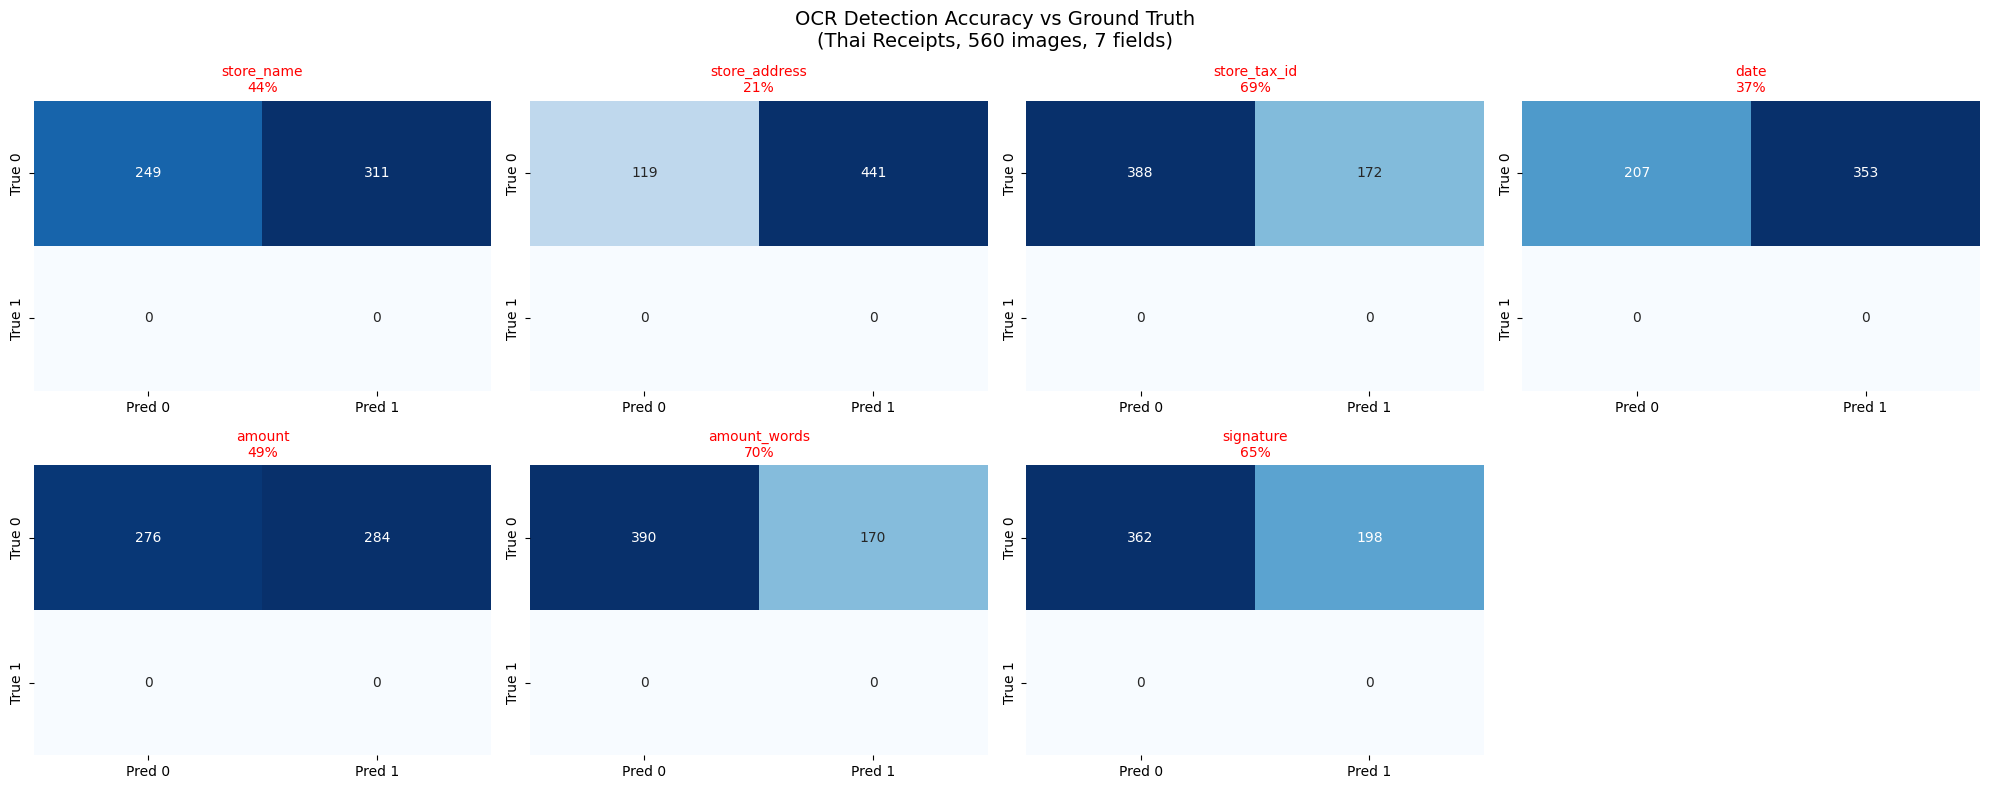

Saved --> field_accuracy_thai.png


In [21]:
gt_df  = pd.read_csv('ground_truth_thai.csv')
ocr_df = pd.read_csv('ocr_results_thai.csv')
 
# ── Debug: show what each file actually contains ──────────────────────
print('GT  columns :', gt_df.columns.tolist())
print('OCR columns :', ocr_df.columns.tolist())
 
merged = pd.merge(gt_df, ocr_df, on='filename', suffixes=('_gt', '_ocr'))
print(f'\nMerged: {len(merged)} rows')
print('Merged columns:', merged.columns.tolist())
 
# ── Only keep FIELDS that actually survived the merge ─────────────────
FIELDS_AVAILABLE = [
    f for f in FIELDS
    if (f + '_gt') in merged.columns and (f + '_ocr') in merged.columns
]
missing = [f for f in FIELDS if f not in FIELDS_AVAILABLE]
if missing:
    print(f'\n⚠ Fields missing from merged result (skipped): {missing}')
print(f'Fields used for comparison: {FIELDS_AVAILABLE}\n')
 
short_names = [f.replace('has_', '') for f in FIELDS_AVAILABLE]
col_w = 10
header_width = 28 + 14 + col_w * len(FIELDS_AVAILABLE)
print('Per-Image Comparison: Ground Truth vs OCR (first 15 images)')
print('-' * header_width)
header = f"{'Filename':<28} {'':14}"
for s in short_names:
    header += f" {s[:col_w]:>{col_w}}"
print(header)
print('-' * header_width)
 
for _, row in merged.head(15).iterrows():
    gt_row = f"{row['filename']:<28} {'GroundTruth':14}"
    for field in FIELDS_AVAILABLE:
        val = int(row[field + '_gt'])
        gt_row += f" {'1(found)' if val else '0(miss)':>{col_w}}"
    print(gt_row)
 
    ocr_row = f"{'':28} {'OCR Result':14}"
    for field in FIELDS_AVAILABLE:
        gt_val  = int(row[field + '_gt'])
        ocr_val = int(row[field + '_ocr'])
        lbl = ('1(found)' if ocr_val else '0(miss)') if ocr_val == gt_val else '** WRONG'
        ocr_row += f" {lbl:>{col_w}}"
    print(ocr_row)
    print()
 
print('=' * 75)
print(f"{'Field':<28} {'GT Sum':>8} {'OCR Sum':>8} {'Accuracy':>10} {'Status':>12}")
print('=' * 75)
 
field_accuracies = {}
for field in FIELDS_AVAILABLE:
    gt_sum  = int(merged[field + '_gt'].sum())
    ocr_sum = int(merged[field + '_ocr'].sum())
    acc = accuracy_score(merged[field + '_gt'], merged[field + '_ocr'])
    field_accuracies[field] = acc
    status = '✓ OK' if acc >= 0.8 else '✗ needs fix'
    print(f"{field:<28} {gt_sum:>8} {ocr_sum:>8} {acc*100:>9.1f}%  {status}")
 
overall = sum(field_accuracies.values()) / len(field_accuracies)
print('=' * 75)
print(f"{'Overall Average':<28} {'':>8} {'':>8} {overall*100:>9.1f}%")
if overall >= 0.8:
    print('\n✓ Accuracy >= 80% --> Ready for training!')
else:
    low = [f for f, a in field_accuracies.items() if a < 0.8]
    print(f'\n✗ Needs improvement: {low}')
 
# ── Confusion matrices (only available fields) ────────────────────────
n = len(FIELDS_AVAILABLE)
cols_plot = 4
rows_plot = (n + cols_plot - 1) // cols_plot   # ceiling division
fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(5 * cols_plot, 4 * rows_plot))
axes = axes.flatten()
 
for idx, field in enumerate(FIELDS_AVAILABLE):
    cm  = confusion_matrix(merged[field + '_gt'], merged[field + '_ocr'], labels=[0, 1])
    acc = field_accuracies[field]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                ax=axes[idx], cbar=False)
    short = field.replace('has_', '')
    color = 'green' if acc >= 0.8 else 'red'
    axes[idx].set_title(f'{short}\n{acc*100:.0f}%', color=color, fontsize=10)
 
for i in range(n, len(axes)):
    axes[i].set_visible(False)
 
plt.suptitle(f'OCR Detection Accuracy vs Ground Truth\n(Thai Receipts, {len(merged)} images, {n} fields)',
             fontsize=14)
plt.tight_layout()
plt.savefig('field_accuracy_thai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> field_accuracy_thai.png')

OCR CSV columns: ['filename', 'has_store_name', 'has_store_address', 'has_store_tax_id', 'has_store_phone', 'has_date', 'has_invoice_number', 'has_item_list', 'has_amount', 'has_vat', 'has_amount_words', 'has_signature', 'label']
Merged columns:  ['filename', 'has_store_name_gt', 'has_store_address_gt', 'has_store_tax_id_gt', 'has_date_gt', 'has_amount_gt', 'has_amount_words_gt', 'has_signature_gt', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id', 'label_gt', 'has_store_name_ocr', 'has_store_address_ocr', 'has_store_tax_id_ocr', 'has_store_phone', 'has_date_ocr', 'has_invoice_number', 'has_item_list', 'has_amount_ocr', 'has_vat', 'has_amount_words_ocr', 'has_signature_ocr', 'label_ocr']

⚠ Skipping missing fields: ['has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id']
✓ Using 7 fields: ['has_store_name', 'has_store_address', 'has_store_tax_id', 'has_date', 'has_amount', 'has_amount_words', 'has_signature']



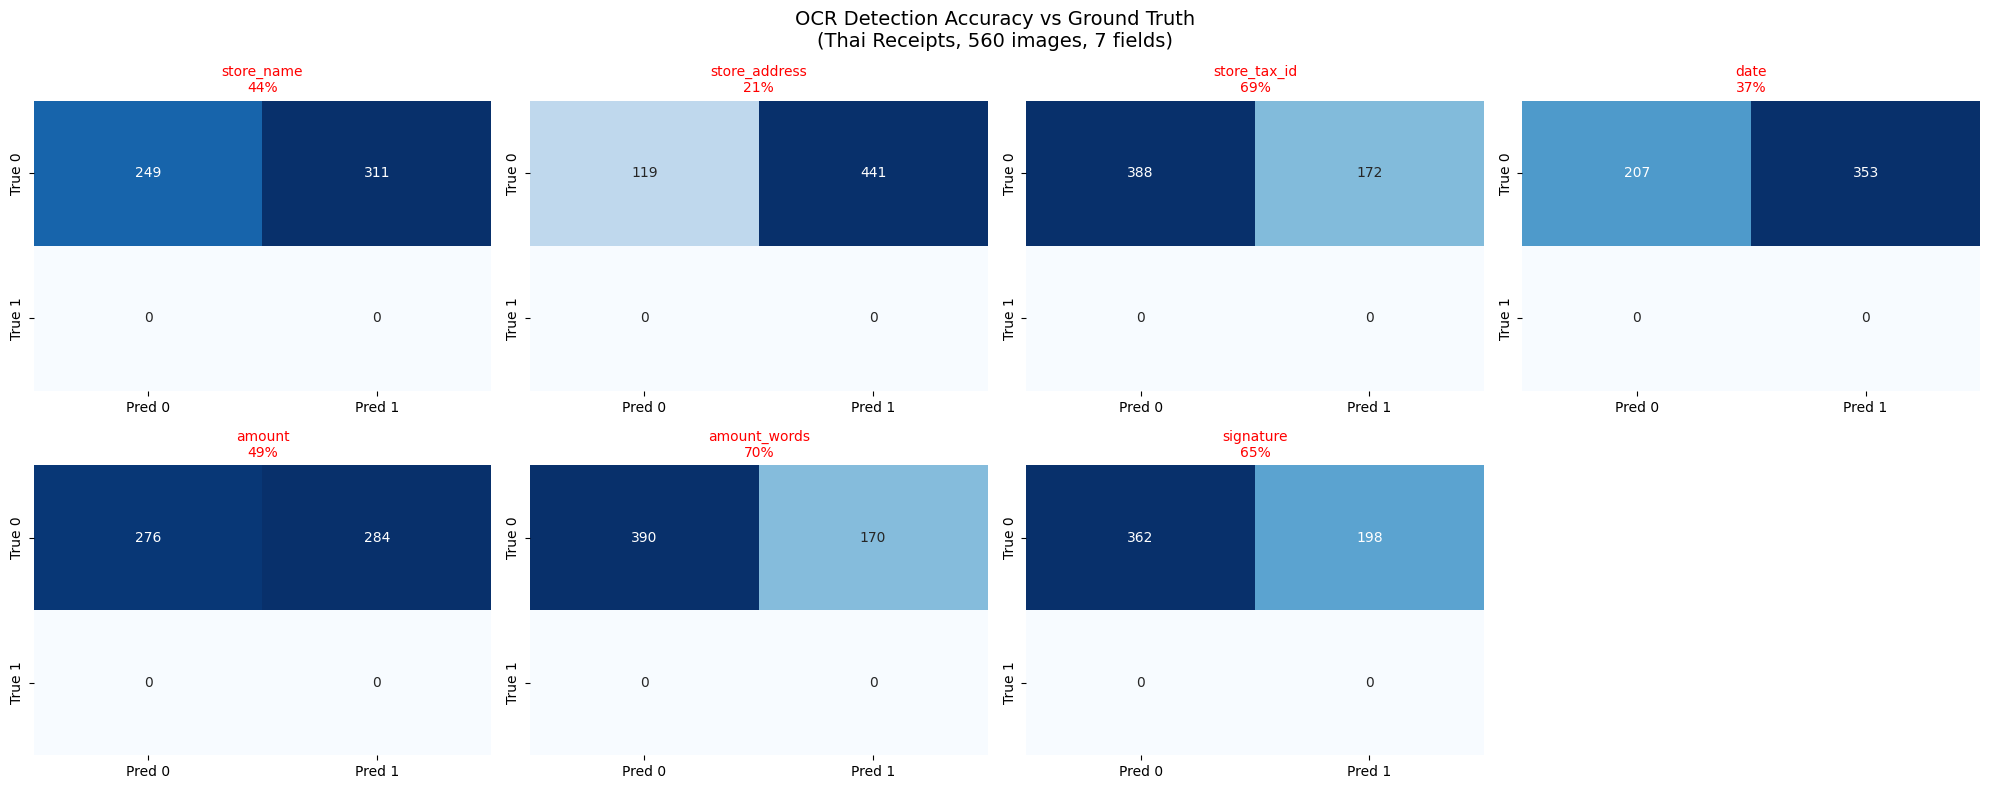

Saved --> field_accuracy_thai.png


In [23]:
print("OCR CSV columns:", ocr_df.columns.tolist())
print("Merged columns: ", merged.columns.tolist())
 
# Only use fields that exist in BOTH sides of the merge
FIELDS_OK = [f for f in FIELDS
             if f + '_gt' in merged.columns and f + '_ocr' in merged.columns]
FIELDS_MISSING = [f for f in FIELDS if f not in FIELDS_OK]
if FIELDS_MISSING:
    print(f"\n⚠ Skipping missing fields: {FIELDS_MISSING}")
print(f"✓ Using {len(FIELDS_OK)} fields: {FIELDS_OK}\n")
 
# ── Step 2: recompute accuracies for available fields only ────────────
field_accuracies = {}
for field in FIELDS_OK:
    field_accuracies[field] = accuracy_score(
        merged[field + '_gt'], merged[field + '_ocr']
    )
 
# ── Step 3: confusion matrices ────────────────────────────────────────
n = len(FIELDS_OK)
cols_plot = 4
rows_plot = (n + cols_plot - 1) // cols_plot
 
fig, axes = plt.subplots(rows_plot, cols_plot,
                         figsize=(5 * cols_plot, 4 * rows_plot))
axes = axes.flatten()
 
for idx, field in enumerate(FIELDS_OK):
    cm = confusion_matrix(
        merged[field + '_gt'], merged[field + '_ocr'], labels=[0, 1]
    )
    acc = field_accuracies[field]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                ax=axes[idx], cbar=False)
    short = field.replace('has_', '')
    axes[idx].set_title(f'{short}\n{acc*100:.0f}%',
                        color='green' if acc >= 0.8 else 'red',
                        fontsize=10)
 
for i in range(n, len(axes)):
    axes[i].set_visible(False)
 
plt.suptitle(
    f'OCR Detection Accuracy vs Ground Truth\n'
    f'(Thai Receipts, {len(merged)} images, {n} fields)',
    fontsize=14
)
plt.tight_layout()
plt.savefig('field_accuracy_thai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> field_accuracy_thai.png')

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
 
# ── Use only fields that actually exist in ocr_df ────────────────────
FIELDS_OK = [f for f in FIELDS if f in ocr_df.columns]
FIELDS_MISSING = [f for f in FIELDS if f not in ocr_df.columns]
if FIELDS_MISSING:
    print(f"⚠ Fields missing from ocr_results_thai.csv (excluded from training): {FIELDS_MISSING}")
    print(f"  → To fix permanently: delete ocr_results_thai.csv and re-run build_dataset()\n")
 
X = ocr_df[FIELDS_OK]
y = ocr_df['label']
 
print(f'Dataset : {len(X)} samples | Fields used: {len(FIELDS_OK)} | Labels: {dict(y.value_counts())}')
 
# ── Guard: can't stratify if only one class exists ───────────────────
n_classes = y.nunique()
if n_classes < 2:
    print("\n⚠ WARNING: Only one class in labels — all values are the same.")
    print("  The model will trivially predict that one class and metrics are meaningless.")
    print("  Fix ground_truth_thai.csv so it has both 0s and 1s before training.\n")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if n_classes >= 2 else None
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}\n')
 
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Linear SVM':          SVC(kernel='linear', probability=True, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
}
 
print(f'--- Thai Receipt Classification ({len(FIELDS_OK)} fields, class_weight=balanced) ---')
print('=' * 75)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('=' * 75)
 
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
                     'y_pred': y_pred, 'model': model}
    print(f"{name:<25} {acc*100:>9.1f}% {prec*100:>9.1f}% {rec*100:>9.1f}% {f1*100:>9.1f}%")
 
print('=' * 75)
best_name = max(results, key=lambda n: results[n]['f1'])
print(f'\nBest model: {best_name} (F1={results[best_name]["f1"]*100:.1f}%)')
print()
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Incomplete (0)', 'Complete (1)'],
                             zero_division=0))

⚠ Fields missing from ocr_results_thai.csv (excluded from training): ['has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id']
  → To fix permanently: delete ocr_results_thai.csv and re-run build_dataset()

Dataset : 560 samples | Fields used: 7 | Labels: {1: np.int64(400), 0: np.int64(160)}
Train: 448 | Test: 112

--- Thai Receipt Classification (7 fields, class_weight=balanced) ---
Model                       Accuracy  Precision     Recall         F1
Logistic Regression            54.5%      78.4%      50.0%      61.1%
Decision Tree                  61.6%      86.3%      55.0%      67.2%
Linear SVM                     54.5%      76.4%      52.5%      62.2%
Random Forest                  67.0%      85.2%      65.0%      73.8%
Gradient Boosting              72.3%      73.8%      95.0%      83.1%

Best model: Gradient Boosting (F1=83.1%)

                precision    recall  f1-score   support

Incomplete (0)       0.56      0.16      0.24        32
  Complete (1)       0.74      0.95      

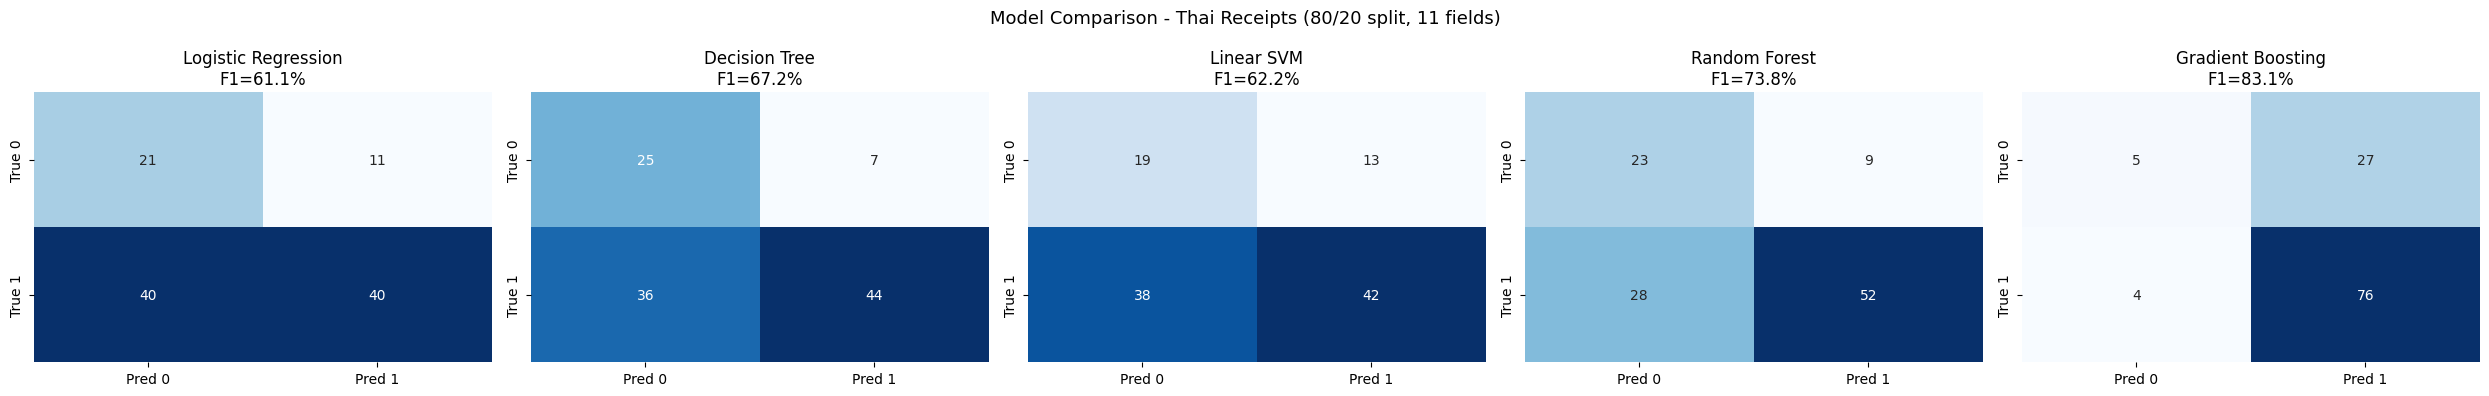

Saved --> model_comparison_thai.png


In [26]:
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nF1={res['f1']*100:.1f}%")
plt.suptitle('Model Comparison - Thai Receipts (80/20 split, 11 fields)', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_thai.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved --> model_comparison_thai.png')


In [27]:
best_model = results[best_name]['model']
best_model.fit(X, y)   # retrain on ALL data
with open('best_model_thai.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'Best model ({best_name}) saved --> best_model_thai.pkl')
print(f'Trained on all {len(X)} samples')
print()
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Incomplete (0)','Complete (1)']))


Best model (Gradient Boosting) saved --> best_model_thai.pkl
Trained on all 560 samples

                precision    recall  f1-score   support

Incomplete (0)       0.56      0.16      0.24        32
  Complete (1)       0.74      0.95      0.83        80

      accuracy                           0.72       112
     macro avg       0.65      0.55      0.54       112
  weighted avg       0.69      0.72      0.66       112

